In [1]:
from matplotlib.lines import Line2D
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import re
import seaborn as sns
import yaml

from _configs.country_config import *
from _configs.files_config import *
from _configs.run_config import *

from _utils.utils import *

Go to root directory

In [2]:
if Path.cwd().name == "_utils":
    os.chdir(Path.cwd().parent)

print(f"Current Directory: {Path.cwd()}")

Current Directory: /work/tuv89272/Calibration_Pipeline_v7_NG-SE


In [3]:
# for all folders starting with validation*

total_monthly_population_dfs = []
total_monthly_population_df_names = []

folders = ["validation_runs/validation_1_0.25_population_scale_one_pattern_20_replicates"]

for folder in folders:
    # print(f"Processing folder: {folder}")
    # get the path to the folder
    folder_path = Path(folder)

    analysis_path = folder_path / "analysis"
    if analysis_path.exists():
        # if there is a file called "total_population_by_month.csv" in the analysis sub directory
        total_population_by_month_path = analysis_path / "total_population_by_month.csv"
        if total_population_by_month_path.exists():
            print(f"Found total_population_by_month.csv in {analysis_path}")
            # read the CSV file into a pandas DataFrame
            df = pd.read_csv(total_population_by_month_path)
            total_monthly_population_dfs.append(df)

            # Match numbers + dot + numbers + M (e.g. 20.5M, 20.38M)
            match = re.search(r'\d+\.\d+M', folder)
            if match:
                folder_label = match.group(0)
            else:
                folder_label = folder  # Fallback if match fails
            
            total_monthly_population_df_names.append(folder_label)


Found total_population_by_month.csv in validation_runs/validation_1_0.25_population_scale_one_pattern_20_replicates/analysis


In [4]:
print(f"Total monthly population DataFrames loaded: {len(total_monthly_population_dfs)}")
print(f"Total monthly population DataFrame names: {total_monthly_population_df_names}")

Total monthly population DataFrames loaded: 1
Total monthly population DataFrame names: ['validation_runs/validation_1_0.25_population_scale_one_pattern_20_replicates']


In [5]:
test_df = total_monthly_population_dfs[0]
test_df

,monthly_data_id,population_0,population_2,population_3,population_4,population_7,population_8,population_9,population_10,population_11,population_12,population_13,population_14,population_15,population_16,population_17,population_18,population_19,mean_population
0,1,20348760.0,20348712.0,20348772.0,20348652.0,20348740.0,20348800.0,20348748.0,20348944.0,20348820.0,20348764.0,20348732.0,20348816.0,20348776.0,20348724.0,20348700.0,20348888.0,20348772.0,20348764
1,2,20361680.0,20361212.0,20361200.0,20361388.0,20361868.0,20362416.0,20361676.0,20361332.0,20361928.0,20362144.0,20361220.0,20362444.0,20361320.0,20362324.0,20361596.0,20361912.0,20360872.0,20361723
2,3,20349100.0,20349792.0,20347912.0,20349072.0,20349176.0,20351624.0,20349204.0,20348708.0,20349444.0,20348784.0,20349052.0,20351236.0,20349660.0,20348860.0,20348896.0,20349456.0,20348008.0,20349422
3,4,20333316.0,20335112.0,20333400.0,20333232.0,20333604.0,20335516.0,20333680.0,20333304.0,20333728.0,20333900.0,20334884.0,20336348.0,20334484.0,20333228.0,20334388.0,20334392.0,20333356.0,20334273
4,5,20324364.0,20326420.0,20324952.0,20324632.0,20324524.0,20326544.0,20322988.0,20322960.0,20324476.0,20325560.0,20325244.0,20329124.0,20325488.0,20324104.0,20325060.0,20325528.0,20325328.0,20325209
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152,153,24582024.0,24577420.0,24571364.0,24574436.0,24576580.0,24577392.0,24562208.0,24572152.0,24572732.0,24581444.0,24579488.0,24565732.0,24555676.0,24571876.0,24576656.0,24571860.0,24567372.0,24572727
153,154,24613204.0,24610356.0,24602276.0,24607024.0,24608776.0,24609360.0,24594508.0,24604896.0,24605680.0,24613548.0,24611608.0,24597804.0,24588488.0,24604936.0,24609136.0,24603420.0,24599332.0,24604959
154,155,24645948.0,24643252.0,24634516.0,24639756.0,24643148.0,24642596.0,24628344.0,24638112.0,24638128.0,24645764.0,24645220.0,24630228.0,24621556.0,24636460.0,24640848.0,24637004.0,24633032.0,24637875
155,156,24678036.0,24674484.0,24667064.0,24672344.0,24676072.0,24673836.0,24660208.0,24669148.0,24670928.0,24678084.0,24677644.0,24661020.0,24654748.0,24668648.0,24672764.0,24670204.0,24665752.0,24670055


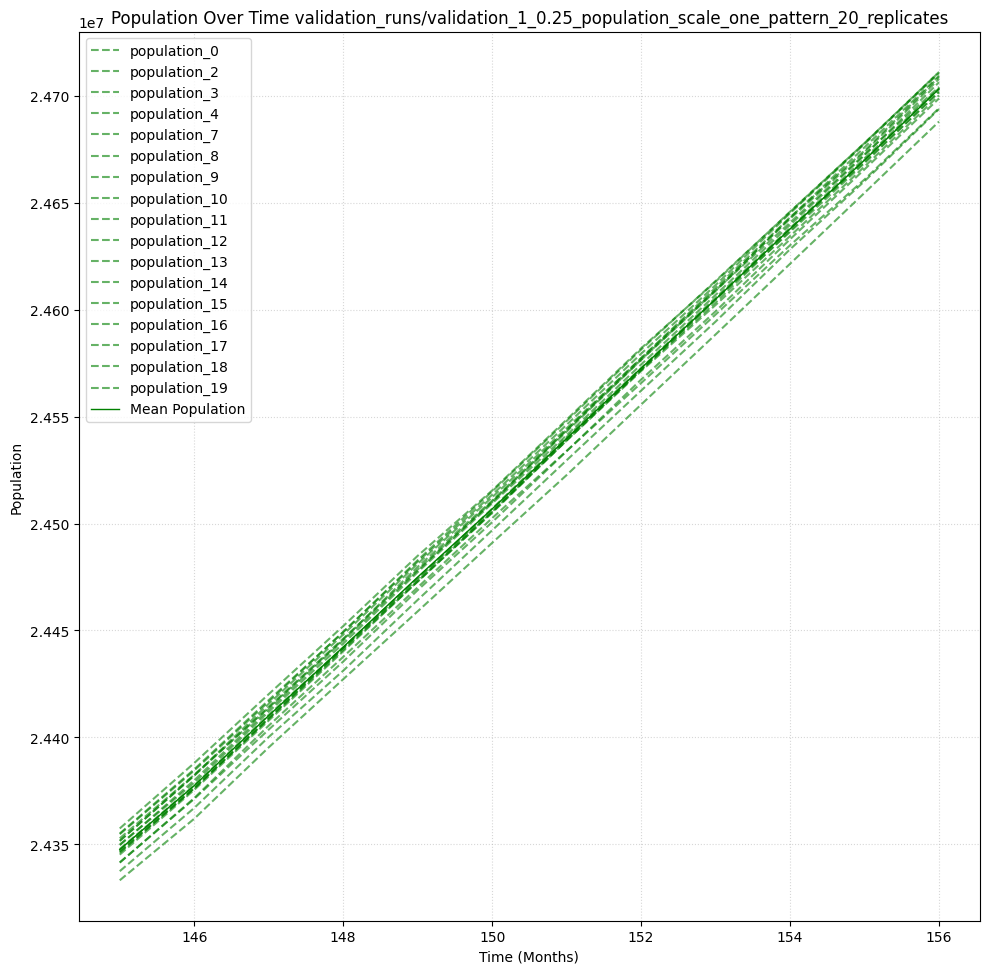

In [6]:
# Define colors for each DataFrame
colors = ['green', 'red', 'darkviolet', 'blue']

for i, df in enumerate(total_monthly_population_dfs):
    # Select color (cycles if there are more DataFrames than colors listed)
    color = colors[i % len(colors)]
    
    plt.figure(figsize=(10, 10))
    
    # 1. Plot numbered population columns as dashed lines
    pop_cols = [col for col in df.columns if col.startswith('population_')]
    for col in pop_cols:
        plt.plot(
            df.tail(12).index, 
            df.tail(12)[col], 
            linestyle='--', 
            color=color, 
            alpha=0.6, 
            label=col
        )
    
    # 2. Plot mean population as a thick solid line
    if 'mean_population' in df.columns:
        plt.plot(
            df.tail(12).index, 
            df.tail(12)['mean_population'], 
            linestyle='-', 
            color=color, 
            linewidth=1, 
            label='Mean Population'
        )
    
    plt.title(f'Population Over Time {total_monthly_population_df_names[i]}')
    plt.xlabel('Time (Months)')
    plt.ylabel('Population')
    plt.legend(loc='upper left')
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.tight_layout()
    plt.show()

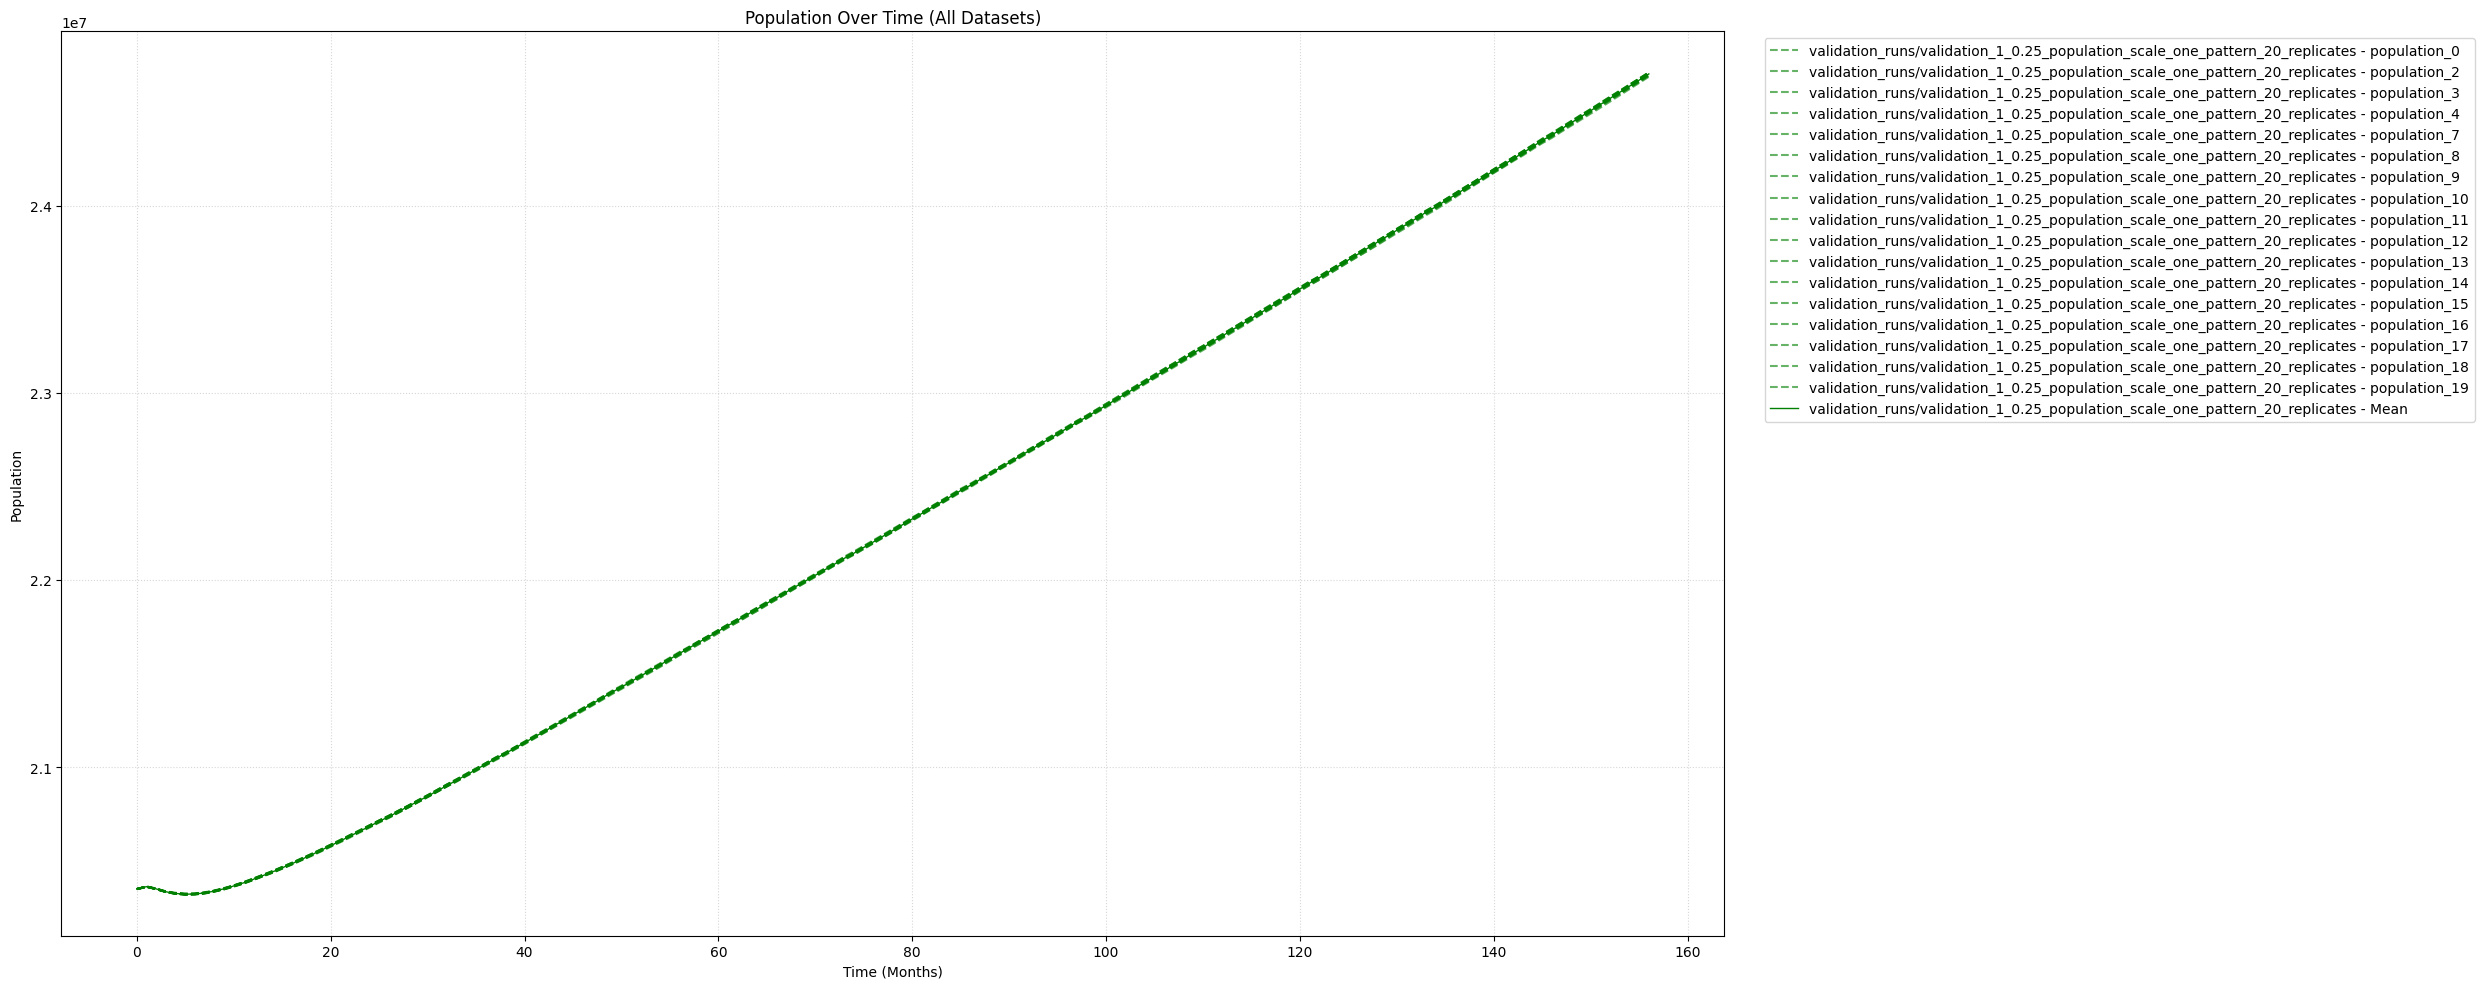

In [7]:
# Initialize a single figure before looping
plt.figure(figsize=(25, 10))

for i, df in enumerate(total_monthly_population_dfs):
    color = colors[i % len(colors)]
    
    # 1. Plot numbered population columns as dashed lines
    pop_cols = [col for col in df.columns if col.startswith('population_')]
    for col in pop_cols:
        plt.plot(
            df.index, 
            df[col], 
            linestyle='--', 
            color=color, 
            alpha=0.6, 
            label=f'{total_monthly_population_df_names[i]} - {col}'
        )
    
    # 2. Plot mean population as a solid line
    if 'mean_population' in df.columns:
        plt.plot(
            df.index, 
            df['mean_population'], 
            linestyle='-', 
            color=color, 
            linewidth=1, 
            label=f'{total_monthly_population_df_names[i]} - Mean'
        )

# Format and display the combined chart after all DataFrames are plotted
plt.title('Population Over Time (All Datasets)')
plt.xlabel('Time (Months)')
plt.ylabel('Population')
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))  # Legend moved outside to prevent overlapping
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

/tmp/ipykernel_942388/2417789978.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))  # Legend moved outside to prevent overlapping


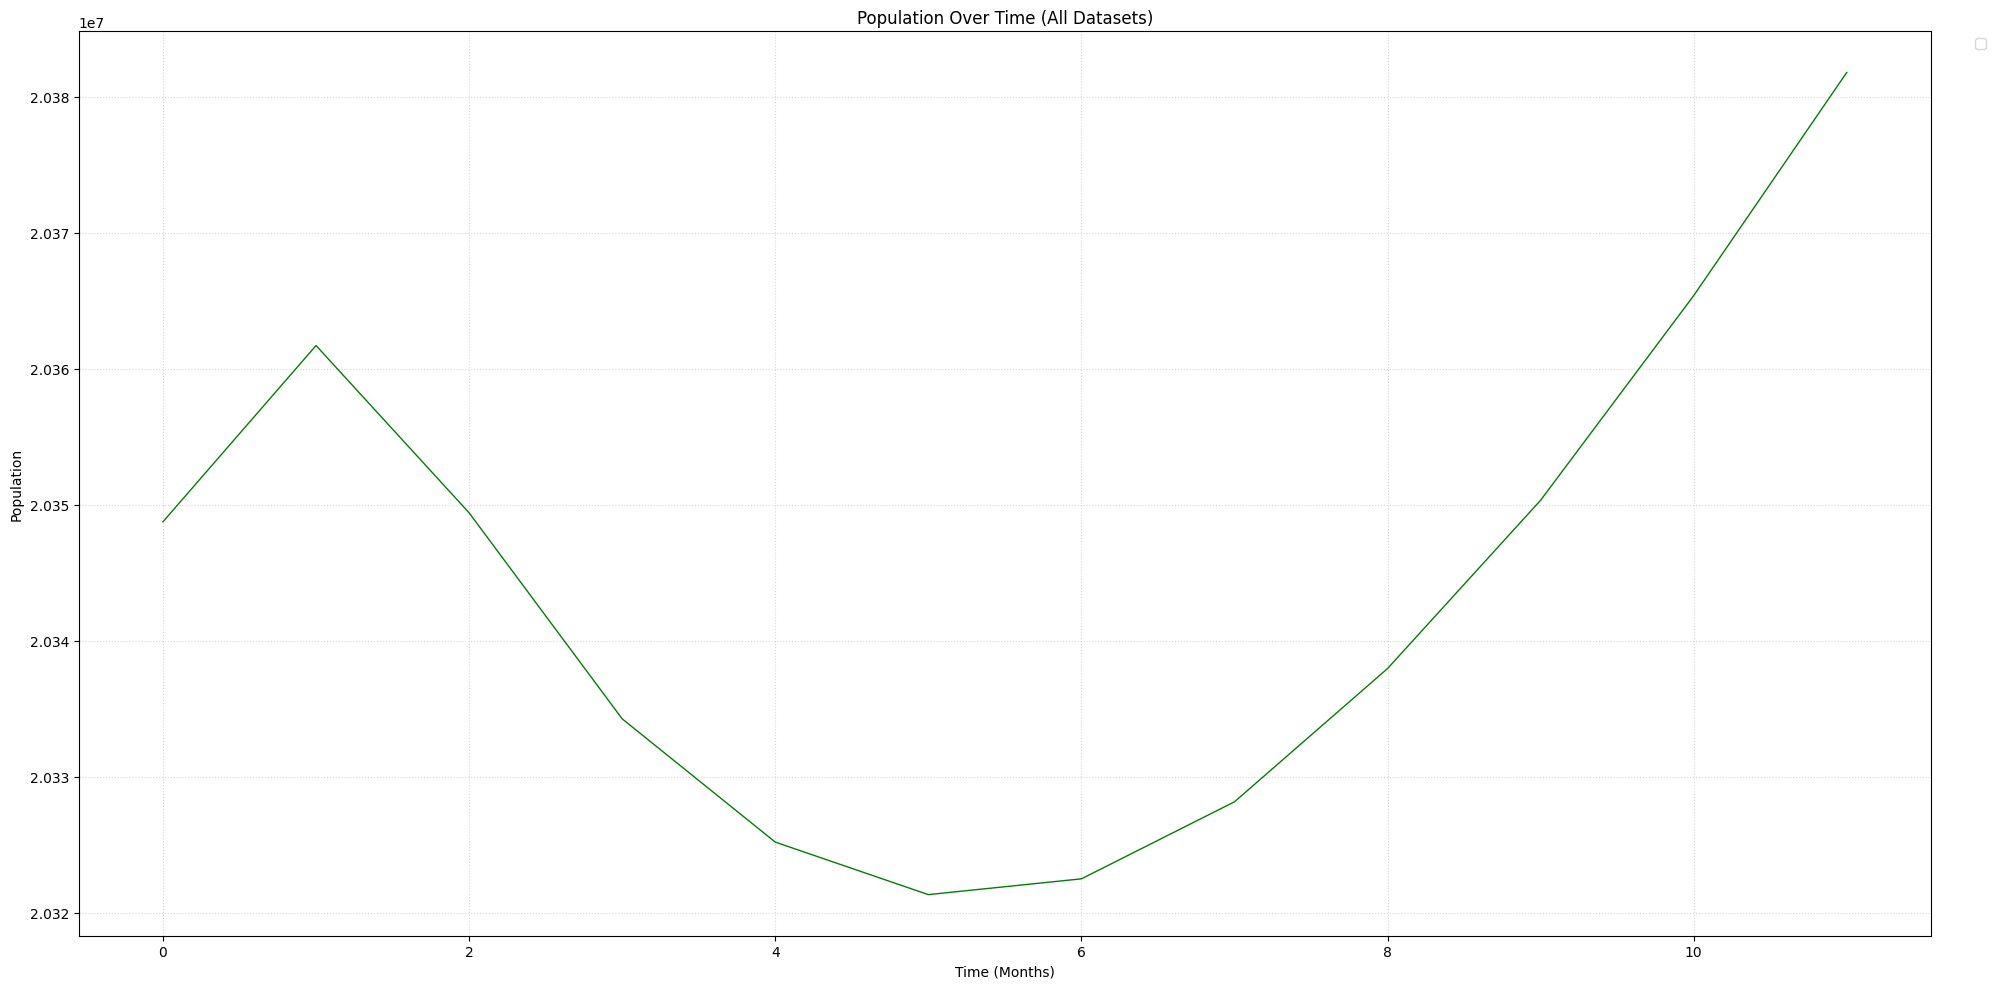

In [8]:
# Initialize a single figure before looping
plt.figure(figsize=(20, 10))

# custom_labels = ["old validation (correct)", "new validation (bug)", "old validation (new treatment seeking)", "old validation (new beta raster)"]

for i, df in enumerate(total_monthly_population_dfs):
    color = colors[i % len(colors)]
    
    # # 1. Plot numbered population columns as dashed lines
    # pop_cols = [col for col in df.columns if col.startswith('population_')]
    # for col in pop_cols:
    #     plt.plot(
    #         df.head(12).index, 
    #         df.head(12)[col], 
    #         linestyle='--', 
    #         color=color, 
    #         alpha=0.6, 
    #         label=f'{total_monthly_population_df_names[i]} - {col}'
    #     )
    
    # 2. Plot mean population as a solid line
    if 'mean_population' in df.columns:
        plt.plot(
            df.head(12).index, 
            df.head(12)['mean_population'], 
            linestyle='-', 
            color=color, 
            linewidth=1, 
            # label=f'{custom_labels[i]} - Mean'
        )

# Format and display the combined chart after all DataFrames are plotted
plt.title('Population Over Time (All Datasets)')
plt.xlabel('Time (Months)')
plt.ylabel('Population')
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))  # Legend moved outside to prevent overlapping
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig(Path(f"analysis/pop_growth_rate_bug.png"), dpi=200)
plt.show()